# 1. Exploratory Data Analysis (EDA)

**Goal:** Perform a thorough analysis of the tools detection dataset,
covering image properties, annotation statistics, class distributions,
and comparative analysis across training and test splits.

**Dataset:** 11 classes of tools in YOLOv8 segmentation format  
**Source:** [Roboflow - Tools](https://universe.roboflow.com/paul-space-qcfcl/tools-bynck-wpynu/dataset/1)

---

### Table of Contents

1. [Setup & Imports](#1.-Setup-&-Imports)
2. [Dataset Overview](#2.-Dataset-Overview)
3. [Image Dimension Analysis](#3.-Image-Dimension-Analysis)
4. [Class Distribution - Original Training Set](#4.-Class-Distribution---Original-Training-Set)
5. [Comparative Distribution: Train vs Test](#5.-Comparative-Distribution:-Train-vs-Test)
6. [Annotation Statistics](#6.-Annotation-Statistics)
7. [Bounding Box Size Analysis](#7.-Bounding-Box-Size-Analysis)
8. [Sample Images with Annotations](#8.-Sample-Images-with-Annotations)
9. [Summary](#9.-Summary)

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml

sys.path.insert(0, str(Path.cwd()))
from utils.config import (
    ORIGINAL_DATASET,
    ORIGINAL_TRAIN_IMAGES, ORIGINAL_TRAIN_LABELS,
    ORIGINAL_TEST_LABELS, ORIGINAL_TEST_IMAGES,
)
from utils.eda_helpers import (
    count_class_distribution, count_images,
    get_annotations_per_image, get_bbox_stats,
    get_image_dimensions, draw_bboxes, dataset_summary,
)

# Read ALL class names directly from dataset yaml (all 11 classes for EDA)
with open(ORIGINAL_DATASET / "data.yaml") as f:
    _data_yaml = yaml.safe_load(f)
CLASS_NAMES = _data_yaml["names"]
NUM_CLASSES = len(CLASS_NAMES)
ID_TO_NAME = {i: n for i, n in enumerate(CLASS_NAMES)}

plt.rcParams["figure.dpi"] = 100
COLORS = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))

## 2. Dataset Overview

Summary statistics for the original dataset splits: training and test sets.

In [2]:
splits = {
    "Original Train": (ORIGINAL_TRAIN_IMAGES, ORIGINAL_TRAIN_LABELS),
    "Original Test":  (ORIGINAL_TEST_IMAGES, ORIGINAL_TEST_LABELS),
}

summary_rows = []
for name, (img_dir, lbl_dir) in splits.items():
    if img_dir.exists() and lbl_dir.exists():
        s = dataset_summary(img_dir, lbl_dir)
        s["split"] = name
        summary_rows.append(s)

df_summary = pd.DataFrame(summary_rows).set_index("split")
df_summary.columns = [
    "Images", "Labels", "Total Annot.", "Classes",
    "Annot/Img Mean", "Annot/Img Std", "Annot/Img Min", "Annot/Img Max",
]

for col in ["Annot/Img Mean", "Annot/Img Std"]:
    df_summary[col] = df_summary[col].round(2)

df_summary

,Images,Labels,Total Annot.,Classes,Annot/Img Mean,Annot/Img Std,Annot/Img Min,Annot/Img Max
split,,,,,,,,
Original Train,4153,4153,7696,11,1.85,3.00,0,80
Original Test,1051,1051,1882,10,1.79,3.02,0,62


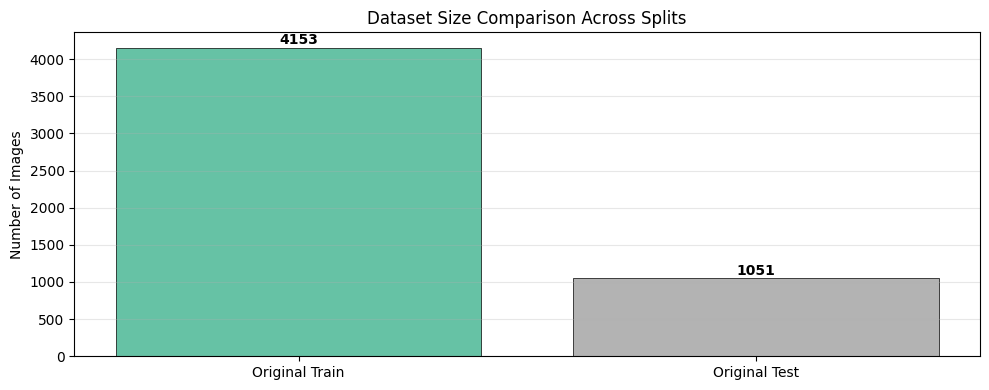

In [3]:
# Image count comparison across splits
fig, ax = plt.subplots(figsize=(10, 4))
split_names = df_summary.index.tolist()
img_counts = df_summary["Images"].tolist()
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(split_names)))

bars = ax.bar(split_names, img_counts, color=bar_colors, edgecolor="black", linewidth=0.5)
for bar, c in zip(bars, img_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(c), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Number of Images")
ax.set_title("Dataset Size Comparison Across Splits")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Image Dimension Analysis

Check image resolutions to understand input variability.
YOLOv8 will resize all images to `imgsz` (e.g., 640x640) during training.

In [4]:
dims = get_image_dimensions(ORIGINAL_TRAIN_IMAGES, sample_limit=200)
df_dims = pd.DataFrame(dims)
df_dims["aspect_ratio"] = df_dims["width"] / df_dims["height"]

print("Image Dimension Statistics (original train, sample of 200):")
print(df_dims[["width", "height", "aspect_ratio"]].describe().round(2))

Image Dimension Statistics (original train, sample of 200):
        width  height  aspect_ratio
count  200.00  200.00        200.00
mean   243.92  210.40          1.20
std     34.43   25.84          0.37
min    178.00  127.00          0.63
25%    225.00  190.75          1.00
50%    225.00  225.00          1.00
75%    264.25  225.00          1.39
max    397.00  283.00          3.13


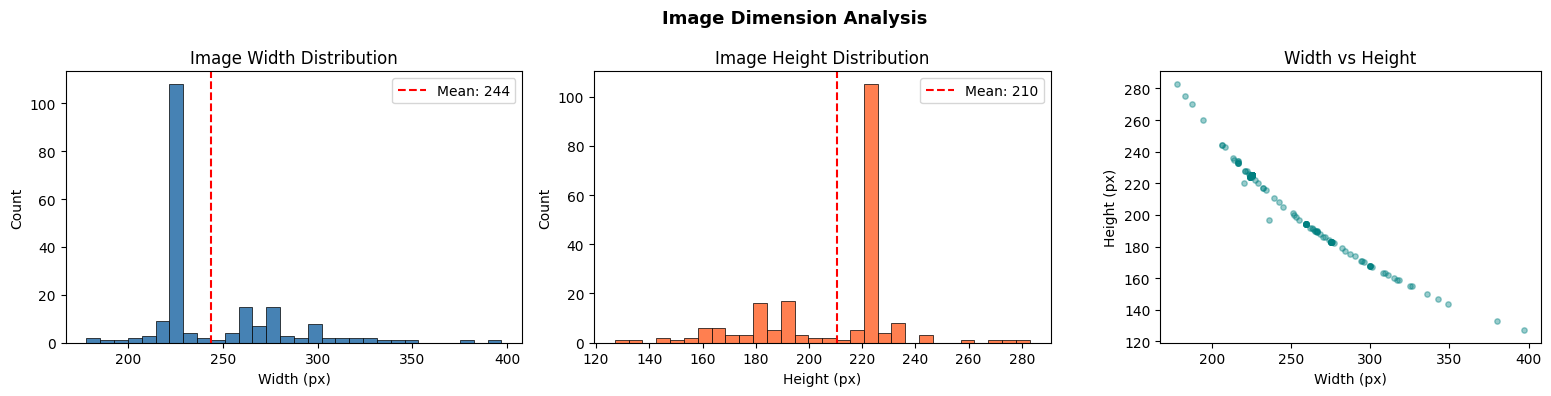

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_dims["width"], bins=30, color="steelblue", edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].set_title("Image Width Distribution")
axes[0].axvline(df_dims["width"].mean(), color="red", linestyle="--",
                label=f'Mean: {df_dims["width"].mean():.0f}')
axes[0].legend()

axes[1].hist(df_dims["height"], bins=30, color="coral", edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].set_title("Image Height Distribution")
axes[1].axvline(df_dims["height"].mean(), color="red", linestyle="--",
                label=f'Mean: {df_dims["height"].mean():.0f}')
axes[1].legend()

axes[2].scatter(df_dims["width"], df_dims["height"], alpha=0.4, s=15, color="teal")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")
axes[2].set_title("Width vs Height")
axes[2].set_aspect("equal")

plt.suptitle("Image Dimension Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Class Distribution - Original Training Set

Annotation count per class in the full original training set
before any balancing. This reveals the natural class imbalance.

In [6]:
original_dist = count_class_distribution(ORIGINAL_TRAIN_LABELS)
n_original = count_images(ORIGINAL_TRAIN_IMAGES)
original_counts = [original_dist.get(i, 0) for i in range(NUM_CLASSES)]

print(f"Training images:    {n_original}")
print(f"Total annotations:  {sum(original_counts)}")
print(f"Classes:            {NUM_CLASSES}")
print(f"\nAnnotation count per class:")
for cid in range(NUM_CLASSES):
    bar_visual = '#' * (original_counts[cid] // 5)
    print(f"  [{cid:2d}] {ID_TO_NAME[cid]:<22s} {original_counts[cid]:4d}  {bar_visual}")

Training images:    4153
Total annotations:  7696
Classes:            11

Annotation count per class:
  [ 0] 0                       493  ##################################################################################################
  [ 1] 1                       418  ###################################################################################
  [ 2] Drill                    81  ################
  [ 3] Hammer                 1697  ###################################################################################################################################################################################################################################################################################################################################################
  [ 4] Hardhat                   1  
  [ 5] Measuring Tape          149  #############################
  [ 6] Pliers                  716  ###########################################################################

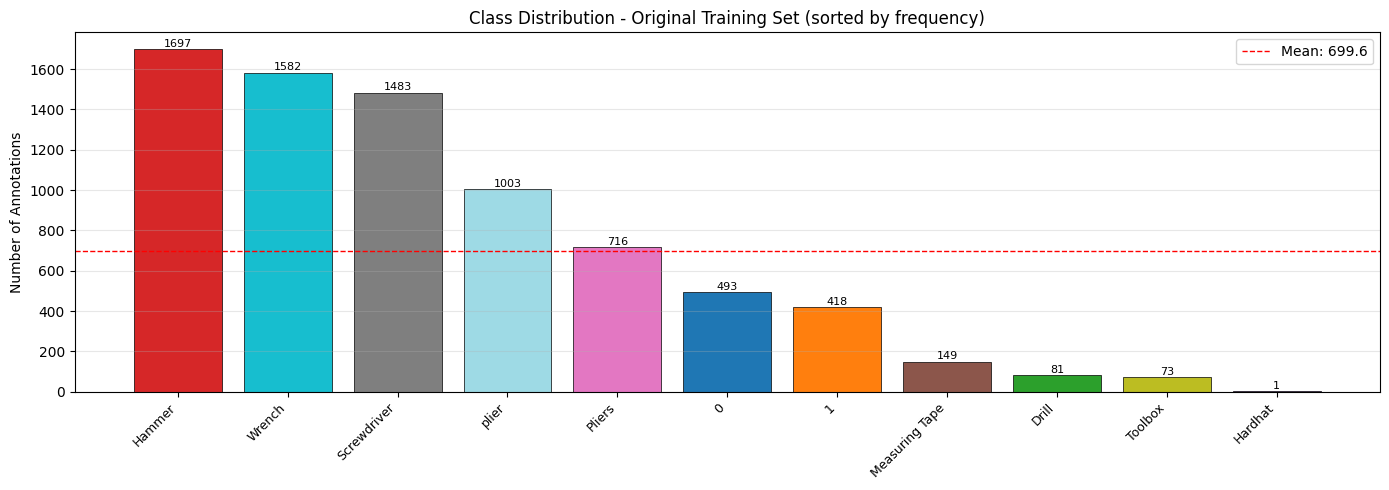

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

sorted_indices = np.argsort(original_counts)[::-1]
sorted_names = [CLASS_NAMES[i] for i in sorted_indices]
sorted_counts = [original_counts[i] for i in sorted_indices]
sorted_colors = [COLORS[i] for i in sorted_indices]

bars = ax.bar(range(NUM_CLASSES), sorted_counts, color=sorted_colors,
              edgecolor="black", linewidth=0.5)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(sorted_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Number of Annotations")
ax.set_title("Class Distribution - Original Training Set (sorted by frequency)")
ax.grid(axis="y", alpha=0.3)

mean_val = np.mean(original_counts)
ax.axhline(mean_val, color="red", linestyle="--", linewidth=1,
           label=f"Mean: {mean_val:.1f}")
ax.legend()

for bar, c in zip(bars, sorted_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(c), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# Imbalance metrics
cv_original = np.std(original_counts) / np.mean(original_counts)
ratio_original = max(original_counts) / max(min(original_counts), 1)

print("Original training set imbalance metrics:")
print(f"  Coefficient of Variation (CV): {cv_original:.3f}")
print(f"  Max/Min ratio:                 {ratio_original:.1f}x")
print(f"  Most frequent:  {CLASS_NAMES[np.argmax(original_counts)]} ({max(original_counts)})")
print(f"  Least frequent: {CLASS_NAMES[np.argmin(original_counts)]} ({min(original_counts)})")

Original training set imbalance metrics:
  Coefficient of Variation (CV): 0.880
  Max/Min ratio:                 1697.0x
  Most frequent:  Hammer (1697)
  Least frequent: Hardhat (1)


## 5. Comparative Distribution: Train vs Test

Side-by-side class distribution for the original training and test splits.

In [9]:
all_distributions = {}
for name, (img_dir, lbl_dir) in splits.items():
    if lbl_dir.exists():
        dist = count_class_distribution(lbl_dir)
        all_distributions[name] = [dist.get(i, 0) for i in range(NUM_CLASSES)]

df_dist = pd.DataFrame(all_distributions, index=CLASS_NAMES)
df_dist

,Original Train,Original Test
0,493,107
1,418,144
Drill,81,23
Hammer,1697,403
Hardhat,1,0
Measuring Tape,149,40
Pliers,716,184
Screwdriver,1483,341
Toolbox,73,10
Wrench,1582,372


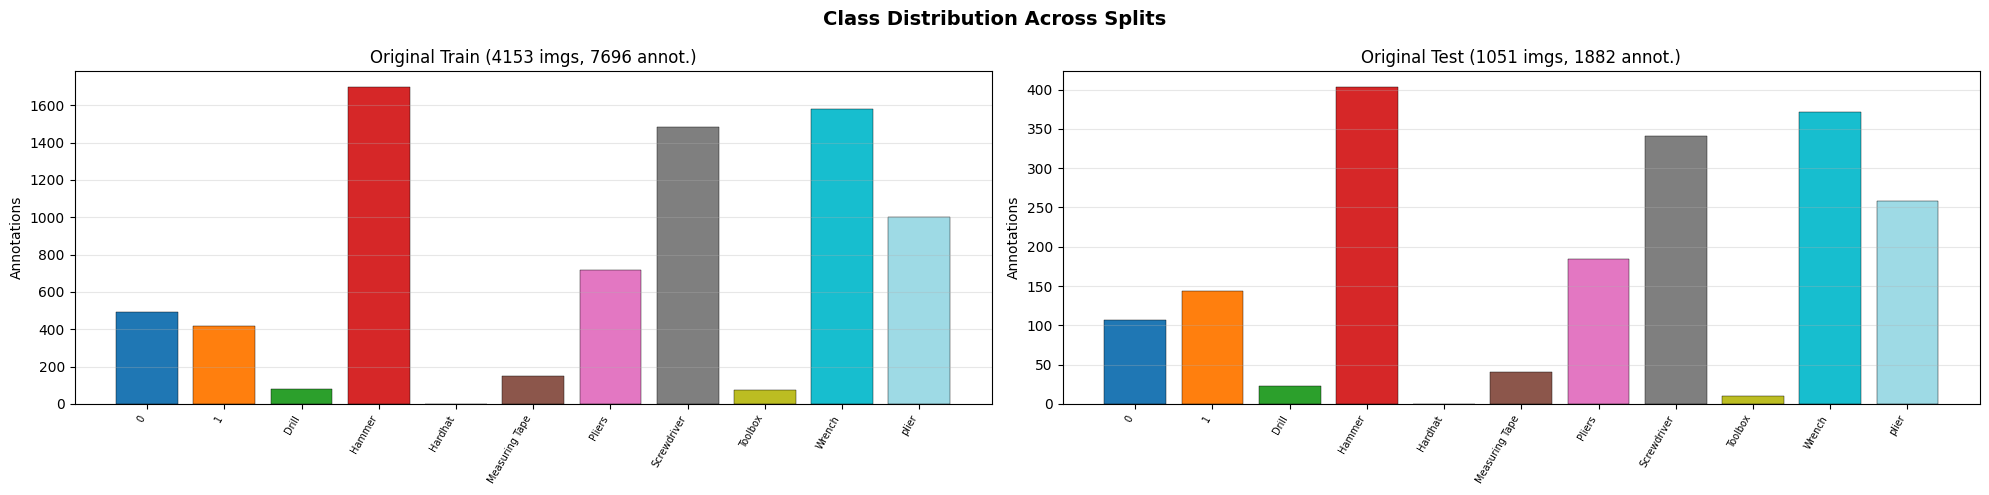

In [10]:
n_dists = len(all_distributions)
fig, axes = plt.subplots(1, n_dists, figsize=(10 * n_dists, 5))
if n_dists == 1:
    axes = [axes]

for idx, (name, counts_list) in enumerate(all_distributions.items()):
    ax = axes[idx]
    ax.bar(range(NUM_CLASSES), counts_list, color=COLORS, edgecolor="black", linewidth=0.3)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=60, ha="right", fontsize=7)
    ax.set_ylabel("Annotations")
    n_imgs = count_images(splits[name][0]) if splits[name][0].exists() else 0
    ax.set_title(f"{name} ({n_imgs} imgs, {sum(counts_list)} annot.)")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Class Distribution Across Splits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

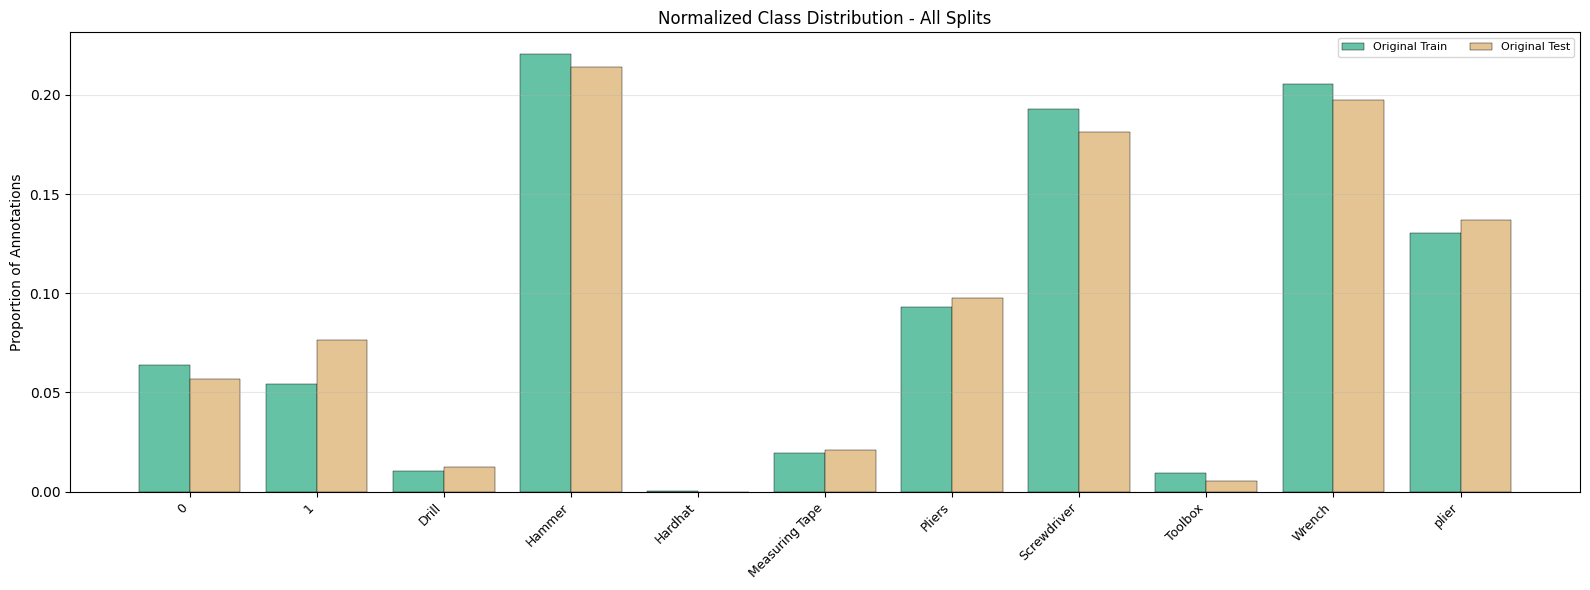

In [11]:
# Normalized distributions (proportions) for fair comparison
df_norm = df_dist.div(df_dist.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(NUM_CLASSES)
n_splits = len(df_norm.columns)
width = 0.8 / n_splits
split_colors = plt.cm.Set2(np.linspace(0, 0.8, n_splits))

for i, col in enumerate(df_norm.columns):
    ax.bar(x + i * width, df_norm[col], width, label=col,
           color=split_colors[i], edgecolor="black", linewidth=0.3)

ax.set_xticks(x + width * (n_splits - 1) / 2)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Proportion of Annotations")
ax.set_title("Normalized Class Distribution - All Splits")
ax.legend(fontsize=8, ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Annotation Statistics

Distribution of bounding boxes per image in the original training set.

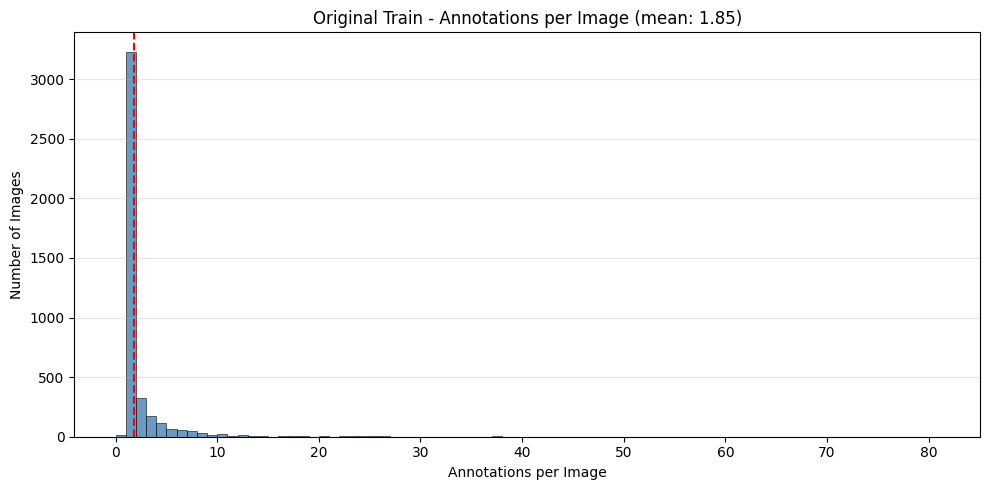

In [12]:
annots_original = get_annotations_per_image(ORIGINAL_TRAIN_LABELS)
counts_per_img_orig = [len(v) for v in annots_original.values()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(counts_per_img_orig, bins=range(0, max(counts_per_img_orig) + 2),
        color="steelblue", edgecolor="black", linewidth=0.5, alpha=0.8)
ax.set_xlabel("Annotations per Image")
ax.set_ylabel("Number of Images")
ax.set_title(f"Original Train - Annotations per Image (mean: {np.mean(counts_per_img_orig):.2f})")
ax.axvline(np.mean(counts_per_img_orig), color="red", linestyle="--")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Bounding Box Size Analysis

Bounding box dimensions (normalized width and height) to understand
object scales in the dataset.

In [13]:
bboxes = get_bbox_stats(ORIGINAL_TRAIN_LABELS)
df_bbox = pd.DataFrame(bboxes)
df_bbox["area"] = df_bbox["width"] * df_bbox["height"]
df_bbox["class_name"] = df_bbox["class_id"].map(ID_TO_NAME)

print(f"Total bounding boxes: {len(df_bbox)}")
print(f"\nBounding box statistics (normalized coordinates):")
print(df_bbox[["width", "height", "area"]].describe().round(4))

Total bounding boxes: 7696

Bounding box statistics (normalized coordinates):
           width     height       area
count  7696.0000  7696.0000  7696.0000
mean      0.4949     0.5289     0.3072
std       0.3402     0.2916     0.3012
min       0.0038     0.0100     0.0002
25%       0.1678     0.2688     0.0526
50%       0.4523     0.5178     0.1931
75%       0.8333     0.7909     0.5023
max       1.0000     1.0000     1.0000


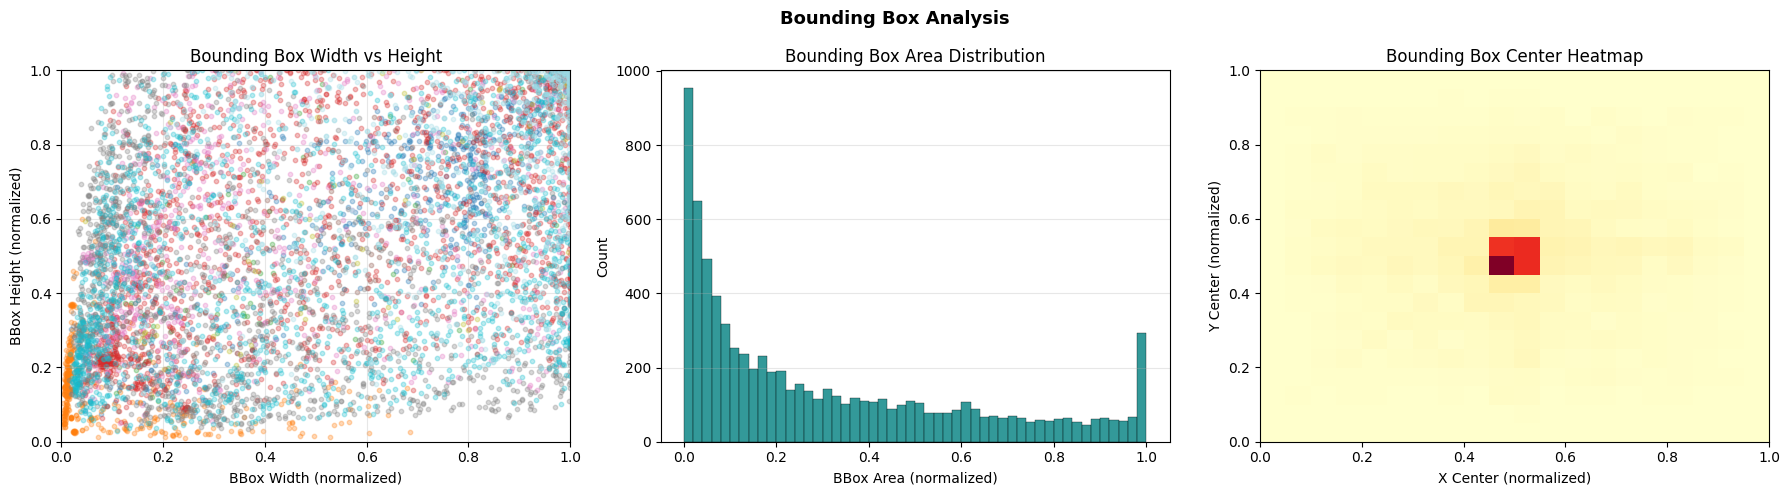

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width vs Height scatter by class
for cid in range(NUM_CLASSES):
    mask = df_bbox["class_id"] == cid
    axes[0].scatter(df_bbox.loc[mask, "width"], df_bbox.loc[mask, "height"],
                    alpha=0.3, s=10, color=COLORS[cid], label=CLASS_NAMES[cid])
axes[0].set_xlabel("BBox Width (normalized)")
axes[0].set_ylabel("BBox Height (normalized)")
axes[0].set_title("Bounding Box Width vs Height")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

# Area distribution
axes[1].hist(df_bbox["area"], bins=50, color="teal", edgecolor="black",
             linewidth=0.3, alpha=0.8)
axes[1].set_xlabel("BBox Area (normalized)")
axes[1].set_ylabel("Count")
axes[1].set_title("Bounding Box Area Distribution")
axes[1].grid(axis="y", alpha=0.3)

# Center position heatmap
heatmap, xedges, yedges = np.histogram2d(
    df_bbox["x_center"], df_bbox["y_center"], bins=20, range=[[0, 1], [0, 1]]
)
axes[2].imshow(heatmap.T, origin="lower", extent=[0, 1, 0, 1],
               cmap="YlOrRd", aspect="auto")
axes[2].set_xlabel("X Center (normalized)")
axes[2].set_ylabel("Y Center (normalized)")
axes[2].set_title("Bounding Box Center Heatmap")

plt.suptitle("Bounding Box Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

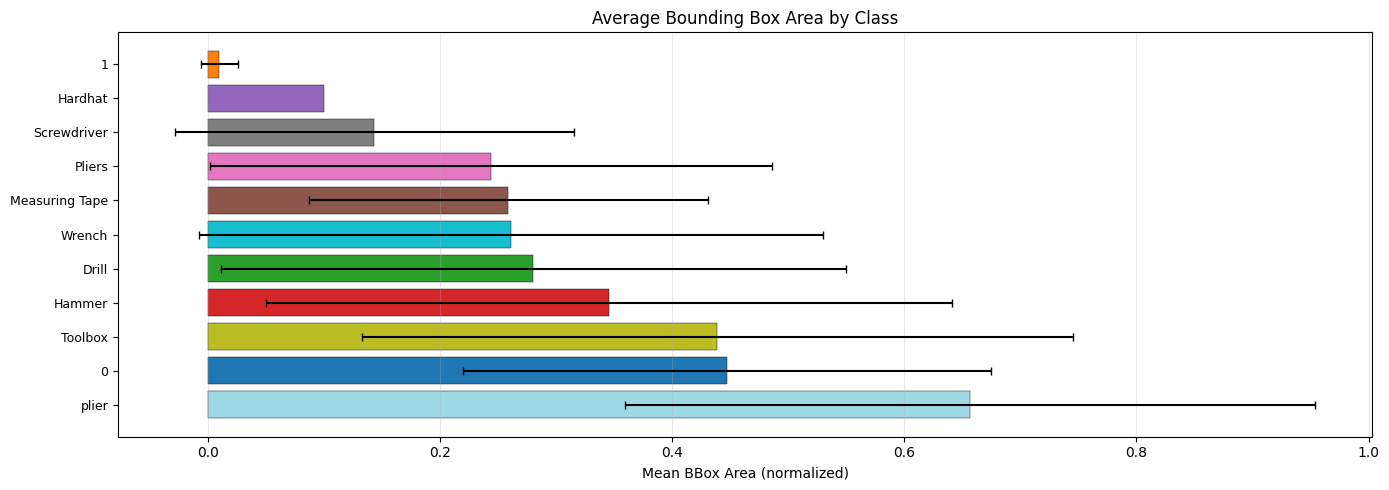

In [15]:
# Average bounding box area per class
area_by_class = df_bbox.groupby("class_id")["area"].agg(["mean", "std", "count"])
area_by_class["class_name"] = [ID_TO_NAME[i] for i in area_by_class.index]
area_by_class = area_by_class.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(range(len(area_by_class)), area_by_class["mean"],
        xerr=area_by_class["std"], color=[COLORS[i] for i in area_by_class.index],
        edgecolor="black", linewidth=0.3, capsize=3)
ax.set_yticks(range(len(area_by_class)))
ax.set_yticklabels(area_by_class["class_name"], fontsize=9)
ax.set_xlabel("Mean BBox Area (normalized)")
ax.set_title("Average Bounding Box Area by Class")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Sample Images with Annotations

Sample images from the **original training set** with bounding boxes
derived from the segmentation polygon labels.

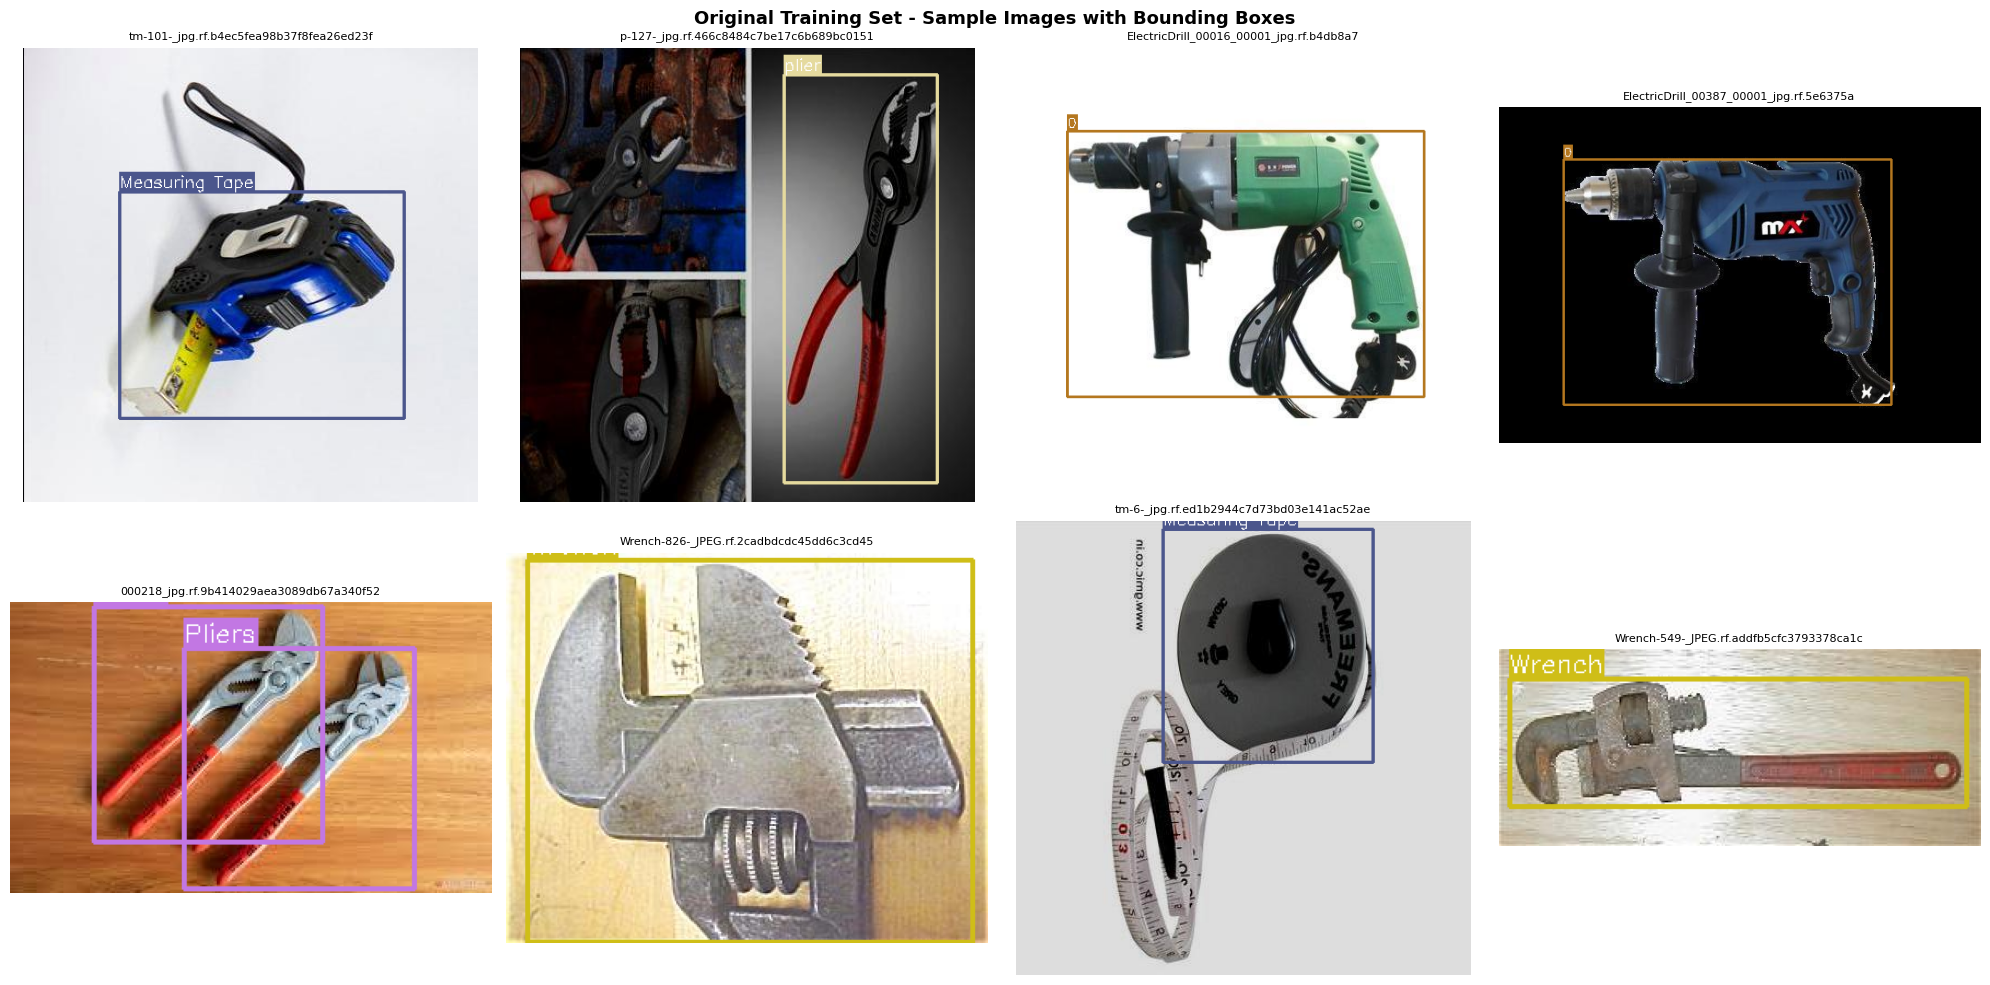

In [17]:
import random as _rng
#_rng.seed(42)

all_imgs = sorted(ORIGINAL_TRAIN_IMAGES.glob("*.jpg"))
sample_imgs = _rng.sample(all_imgs, min(8, len(all_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, img_path in zip(axes.flat, sample_imgs):
    label_path = ORIGINAL_TRAIN_LABELS / f"{img_path.stem}.txt"
    img_with_boxes = draw_bboxes(img_path, label_path, CLASS_NAMES, COLORS)
    img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(img_path.stem[:40], fontsize=8)
    ax.axis("off")

for ax in axes.flat[len(sample_imgs):]:
    ax.axis("off")

plt.suptitle("Original Training Set - Sample Images with Bounding Boxes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Summary

### Key findings

- **Dataset size:** 4153 training images and 1051 test images across 11 classes
- **Class imbalance:** Significant imbalance exists. Only 4 classes (Hammer, Wrench, Screwdriver, Pliers/plier) have substantial annotations; the remaining 7 have very few
- **Duplicate class:** `Pliers` (class 6) and `plier` (class 10) are the same tool with inconsistent naming
- **Multi-label:** Images may contain multiple objects from different classes
- **Object scales:** Bounding box sizes vary considerably across classes
- **Segmentation labels:** Original annotations are silhouette polygons; bboxes are derived from polygon extents

### Design decision

Due to the severe class imbalance and the naming duplicate, the project will
proceed with the **top 4 classes** (merging Pliers + plier) in the data
preparation stage (Notebook 2). The filtering and split creation are
documented and justified there.